In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

BASE_PATH = "/content/drive/MyDrive/ML_Project_NEU/NEU-DET"

train_dir = os.path.join(BASE_PATH, "train/images")
val_dir = os.path.join(BASE_PATH, "validation/images")

In [3]:
classes = sorted(os.listdir(train_dir))
print(classes)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [4]:
image_paths = []
labels = []

for label, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)

    for img in os.listdir(cls_path):
        image_paths.append(os.path.join(cls_path, img))
        labels.append(label)

In [5]:
print(image_paths[0], labels[0])

/content/drive/MyDrive/ML_Project_NEU/NEU-DET/train/images/crazing/crazing_13.jpg 0


In [6]:
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

print(class_to_idx)

{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [7]:
from collections import Counter
print(Counter(labels))

Counter({0: 240, 1: 240, 2: 240, 3: 240, 4: 240, 5: 240})


In [8]:
from sklearn.model_selection import train_test_split

train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.25, stratify=labels, random_state=42
)

In [9]:
print(len(train_paths), len(test_paths))

1080 360


In [10]:
from collections import Counter

print("Train:", Counter(train_labels))
print("Test:", Counter(test_labels))

Train: Counter({4: 180, 3: 180, 0: 180, 2: 180, 1: 180, 5: 180})
Test: Counter({5: 60, 1: 60, 3: 60, 2: 60, 4: 60, 0: 60})


In [11]:
val_paths = []
val_labels = []

for label, cls in enumerate(classes):
    cls_path = os.path.join(val_dir, cls)

    for img in os.listdir(cls_path):
        val_paths.append(os.path.join(cls_path, img))
        val_labels.append(label)

In [12]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [13]:
from torch.utils.data import Dataset
from PIL import Image

class NEUDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [14]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(NEUDataset(train_paths, train_labels, transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(NEUDataset(val_paths, val_labels, transform), batch_size=BATCH_SIZE)
test_loader = DataLoader(NEUDataset(test_paths, test_labels, transform), batch_size=BATCH_SIZE)

In [15]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [16]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(len(classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10

In [17]:
train_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1 | Loss: 1.3597 | Val Acc: 0.5722
Epoch 2 | Loss: 0.6652 | Val Acc: 0.6944
Epoch 3 | Loss: 0.3632 | Val Acc: 0.7000
Epoch 4 | Loss: 0.2928 | Val Acc: 0.7083
Epoch 5 | Loss: 0.2260 | Val Acc: 0.7500
Epoch 6 | Loss: 0.1839 | Val Acc: 0.7500
Epoch 7 | Loss: 0.2258 | Val Acc: 0.7944
Epoch 8 | Loss: 0.2106 | Val Acc: 0.8389
Epoch 9 | Loss: 0.0930 | Val Acc: 0.8917
Epoch 10 | Loss: 0.0662 | Val Acc: 0.8806


In [18]:
import pandas as pd

df = pd.DataFrame({
    "Epoch": list(range(1, EPOCHS+1)),
    "Train Loss": train_losses,
    "Validation Accuracy": val_accuracies
})

df.to_excel("/content/drive/MyDrive/ML_Project_NEU/results.xlsx", index=False)

In [19]:
details = {
    "Batch Size": BATCH_SIZE,
    "Epochs": EPOCHS,
    "Optimizer": "Adam",
    "Learning Rate": 0.001,
    "Loss Function": "CrossEntropyLoss",
    "Classes": len(classes)
}

pd.DataFrame([details]).to_excel("/content/drive/MyDrive/ML_Project_NEU/model_details.xlsx", index=False)

In [20]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("Test Accuracy:", correct/total)

Test Accuracy: 0.95


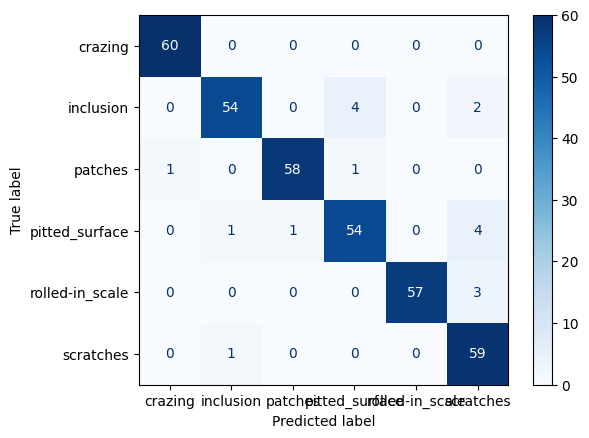

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues')

plt.savefig("/content/drive/MyDrive/ML_Project_NEU/confusion_matrix.png")

plt.show()

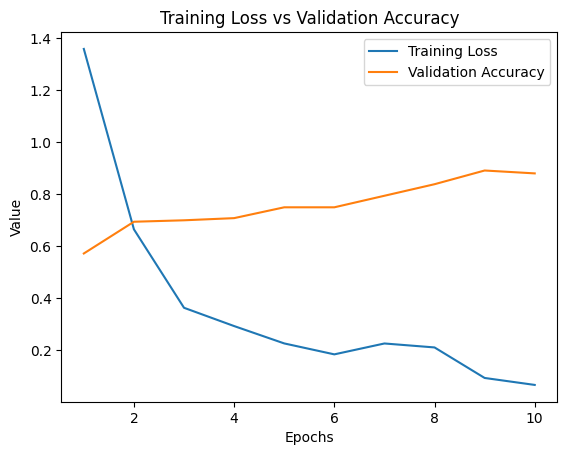

In [22]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()

# Plot Loss
plt.plot(epochs, train_losses, label='Training Loss')

# Plot Validation Accuracy
plt.plot(epochs, val_accuracies, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Loss vs Validation Accuracy')
plt.legend()

plt.show()

In [23]:
plt.savefig("/content/drive/MyDrive/ML_Project_NEU/training_graph.png")

<Figure size 640x480 with 0 Axes>

In [24]:
import pandas as pd

full_details = {
    "Batch Size": 32,
    "Epochs": EPOCHS,
    "Optimizer": "Adam",
    "Learning Rate": 0.001,
    "Loss Function": "CrossEntropyLoss",
    "Input Size": "224x224",
    "Number of Classes": len(classes),
    "Train Samples": len(train_paths),
    "Validation Samples": len(val_paths),
    "Test Samples": len(test_paths),
    "Best Validation Accuracy": max(val_accuracies),
    "Final Test Accuracy": correct/total
}

pd.DataFrame([full_details]).to_excel(
    "/content/drive/MyDrive/ML_Project_NEU/full_model_details.xlsx",
    index=False
)

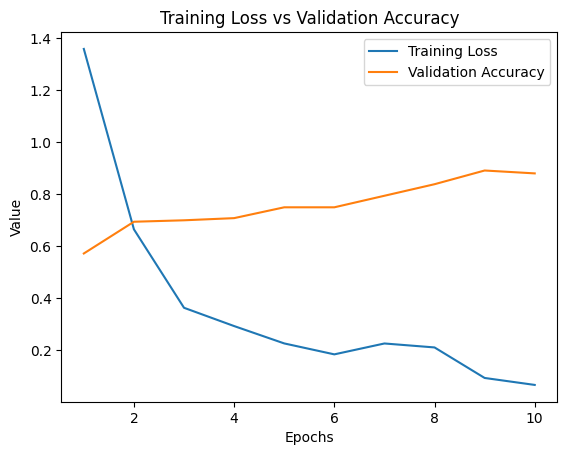

In [25]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()

plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Loss vs Validation Accuracy')
plt.legend()

plt.savefig("/content/drive/MyDrive/ML_Project_NEU/training_graph.png")

plt.show()

In [27]:
torch.save(model.state_dict(), "/content/drive/MyDrive/ML_Project_NEU/model.pth")

In [28]:
import json

with open("/content/drive/MyDrive/ML_Project_NEU/class_mapping.json", "w") as f:
    json.dump(class_to_idx, f)